<hr>

# ℹ️ DATA COLLECTION


<style>
h1 {
    text-align: left;
    color: blue;
    font-weight: bold;
}

</style>
<hr>

```text
DATA COLLECTION Steps:

1) Data Browsing & Downloading 
using data sources:
- https://opendata.paris.fr/pages/home/
- https://data.iledefrance.fr/pages/home-open-data/

//Data Validation (sabina validating dataset)

2) Data Exploration (understand data and take notes)
    
    a) Data Selection
    - DVF (2020-S2 to 2025-S1) 6 large files in the format of .txt
    - arrondissements.csv
    - communes.csv
    - Amentities Tool https://overpass-turbo.eu/
    - Rent data in/outside Paris APIs https://www.observatoire-des-loyers.fr/

    b) Data Loading & Saving
    - DVF 6 TXT files merged  into 1 CSV with selected columns:
    - arrondissements.csv file with seelected columns:
    - communes.csv file with selected columns:

    c) Notes for Data cleaning, Analysis, ML

```

---
<style>
h3 {
    margin-top: 0px;
    margin-bottom: 0px;
    font-weight: bold;
}
</style>

### 📂 IMPORTs

In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sns

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200) # to display all columns in the dataframe

<hr>

## 1 - DATA BROWSING & DOWNLOADING


<style>
h1 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>
<hr>

using data sources:
- https://opendata.paris.fr/pages/home/
- https://data.iledefrance.fr/pages/home-open-data/


In [ ]:

# dictionary for Raw data downloadable links 
links = {
    "arrondissements": "https://drive.google.com/uc?export=download&id=1bSUODphKIH01iwxVll5mBqyXaRuHbkGN",
    "communes": "https://drive.google.com/uc?export=download&id=1RVVusBovovbjQnPLgeDEbpzu-1Whakx4",
    "residences-universitaires": "https://drive.google.com/uc?export=download&id=1WUacgZI2yIrLcuKVfVmXRU7SHbtW-QEb",
    "statuts-doccupation-des-residences-principales": "https://drive.google.com/uc?export=download&id=18oD7xM4RYKH4tI4w4fkLle5VFPDITYrvink",
    "lignes-de-transport-en-commun": "https://drive.google.com/uc?export=download&id=1DKSyojyZvjG9YeJBNbxpIq2oVpSUa_kX",
    "ValeursFoncieres-2020-S2": "https://drive.google.com/uc?export=download&id=1pZvuYyOKn1OuCnTMC6WnqpBt1VgMdeh5",    
    "ValeursFoncieres-2021": "https://drive.google.com/uc?export=download&id=1q_gW41roBD641jtboYa1L14MlRqBolcj",    
    "ValeursFoncieres-2022": "https://drive.google.com/uc?export=download&id=1gLxo0Og5ugIfGMqyUeFfnU7mhZ_MX_tG",    
    "ValeursFoncieres-2023": "https://drive.google.com/uc?export=download&id=1K0kFXN_zpsugh5QysLQJoOj5Zbkb4vWA",    
    "ValeursFoncieres-2024": "https://drive.google.com/uc?export=download&id=1x1wpgIchhRViyD14d8rcfjaQVNR0R6Q9",    
    "ValeursFoncieres-2025": "https://drive.google.com/uc?export=download&id=1X_Fm6xrA0bi-PMmeJ6QTXKHCx5rkNeEz"
}


# download files from links
'''
# download files in ../data/raw/ folder
for name, link in links.items():
    # download file using wget
    !wget -O ../data/raw/{name}.csv {link}
'''

### **VALEURS FONCIERES 2020-2025 🧮**

In [5]:
import pandas as pd

dvf_files = [
    "../data/raw/ValeursFoncieres-2020-S2.txt",
    "../data/raw/ValeursFoncieres-2021.txt",
    "../data/raw/ValeursFoncieres-2022.txt",
    "../data/raw/ValeursFoncieres-2023.txt",
    "../data/raw/ValeursFoncieres-2024.txt",
    "../data/raw/ValeursFoncieres-2025-S1.txt"
]

usecols = [
    "Date mutation",
    "Valeur fonciere",
    "Commune",
    "Code postal",
    "Type local",
    "Surface reelle bati",
    "Nombre pieces principales"
]

# ✅ Your desired output file
output_file = "../data/processed/ValeursFoncieres_all.csv"

with open(output_file, "w", newline="", encoding="utf-8") as f_out:
    header_written = False

    for file in dvf_files:
        print(f"Processing: {file}")

        for chunk in pd.read_csv(
            file,
            sep="|",
            usecols=usecols,
            chunksize=50_000,
            encoding="latin-1",
            decimal=",",
            low_memory=True
        ):
            # Clean numeric columns
            chunk["Valeur fonciere"] = pd.to_numeric(
                chunk["Valeur fonciere"], errors="coerce"
            )
            chunk["Surface reelle bati"] = pd.to_numeric(
                chunk["Surface reelle bati"], errors="coerce"
            )

            # Drop useless rows early
            chunk = chunk.dropna(subset=["Valeur fonciere"])

            # Write to final CSV
            chunk.to_csv(
                f_out,
                index=False,
                header=not header_written
            )

            header_written = True
            del chunk  # free memory

print("✅ File saved at ../data/processed/ValeursFoncieres_all.csv")

Processing: ../data/raw/ValeursFoncieres-2020-S2.txt
Processing: ../data/raw/ValeursFoncieres-2021.txt
Processing: ../data/raw/ValeursFoncieres-2022.txt
Processing: ../data/raw/ValeursFoncieres-2023.txt
Processing: ../data/raw/ValeursFoncieres-2024.txt
Processing: ../data/raw/ValeursFoncieres-2025-S1.txt
✅ File saved at ../data/processed/ValeursFoncieres_all.csv


In [6]:
df = pd.read_csv("../data/processed/ValeursFoncieres_all.csv")
print(df.shape)
display(df.head())

(19908349, 7)


,Date mutation,Valeur fonciere,Code postal,Commune,Type local,Surface reelle bati,Nombre pieces principales
0,01/07/2020,31234.16,1560.0,SAINT-JULIEN-SUR-REYSSOUZE,NaN,NaN,NaN
1,01/07/2020,278000.00,1250.0,CORVEISSIAT,NaN,NaN,NaN
2,01/07/2020,278000.00,1250.0,CORVEISSIAT,NaN,NaN,NaN
3,01/07/2020,278000.00,1250.0,CORVEISSIAT,NaN,NaN,NaN
4,01/07/2020,278000.00,1250.0,SIMANDRE-SUR-SURAN,NaN,NaN,NaN


DVF dataset is used for:

- 📈 Price prediction
- 📊 Market trends
- 🤖 ML models

🎯 TARGET VARIABLE = Valeur fonciere (price)

In [7]:
df["Type local"].unique()

array([nan, 'Maison', 'DÃ©pendance', 'Appartement',
       'Local industriel. commercial ou assimilÃ©'], dtype=object)

### MARKET TRENDS

**PLOT : Linear chart for 5-6 years TRENDS(Date mutation) Type local(line coloured) vs Valeur fonciere(y-axis)**

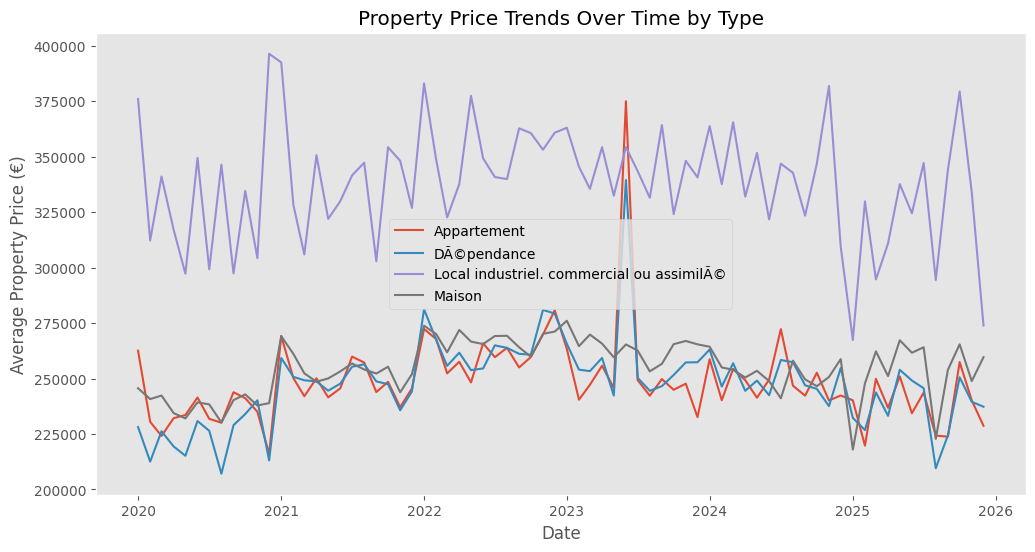

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your combined dataset
# df = pd.read_csv("../data/processed/ValeursFoncieres_all.csv")

# Convert date
df["Date mutation"] = pd.to_datetime(df["Date mutation"], errors="coerce")

# Keep only useful rows
df = df.dropna(subset=["Valeur fonciere", "Type local"])

# Optional: remove extreme outliers (recommended)
df = df[df["Valeur fonciere"] < 2_000_000]

# Create year-month column
df["year_month"] = df["Date mutation"].dt.to_period("M")

# Aggregate: mean price per month per property type
df_grouped = df.groupby(["year_month", "Type local"])["Valeur fonciere"].mean().reset_index()

# Convert back to timestamp for plotting
df_grouped["year_month"] = df_grouped["year_month"].dt.to_timestamp()

# Plot
plt.figure(figsize=(12, 6))

for property_type in df_grouped["Type local"].unique():
    subset = df_grouped[df_grouped["Type local"] == property_type]
    plt.plot(subset["year_month"], subset["Valeur fonciere"], label=property_type)

plt.xlabel("Date")
plt.ylabel("Average Property Price (€)")
plt.title("Property Price Trends Over Time by Type")
plt.legend()
plt.grid()

plt.show()

**PLOT : Linear chart 2020-2025 PROPERTY_TYPE/PRICE TRENDS (price per m²)**

to clearly see:
- 📈 Market growth over 5–6 years
- 🏠 Difference between houses vs apartments
- 📉 Market dips (e.g., COVID effects)

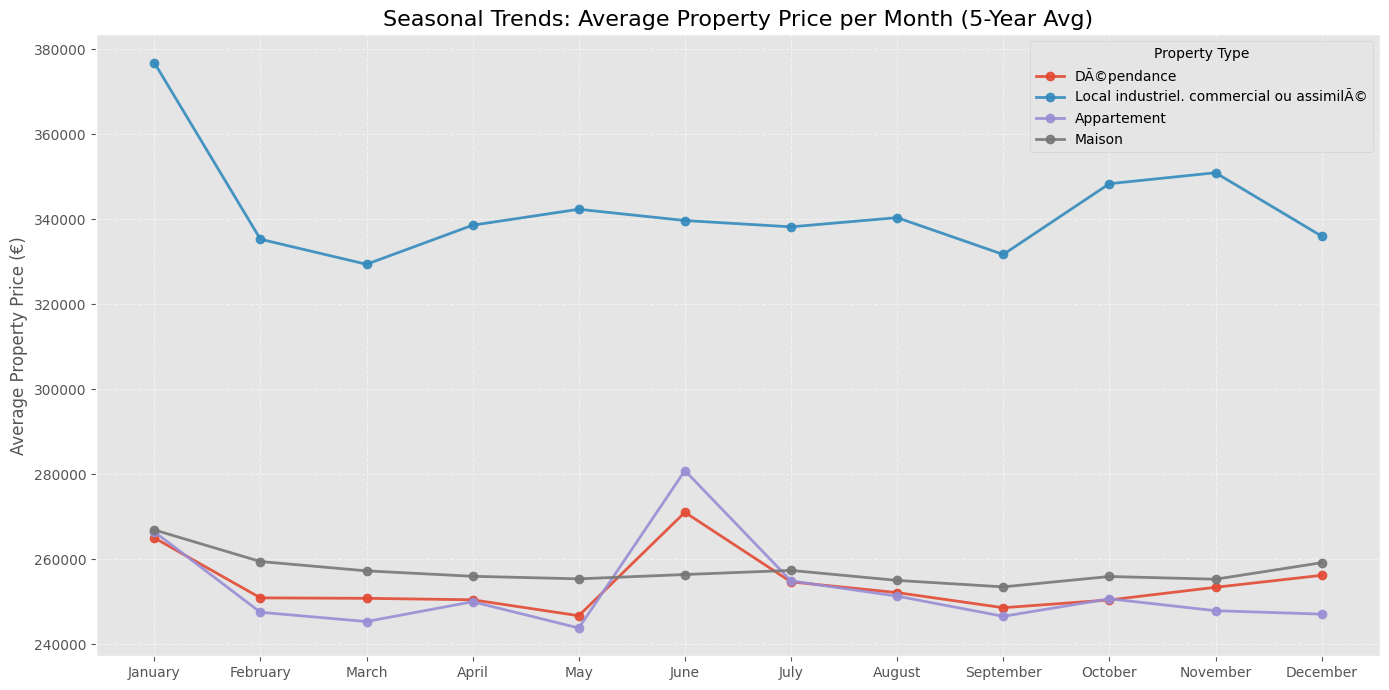

Monthly averages across 5 years:
Type local  Appartement  DÃ©pendance  \
Month_Name                             
January        266449.0     265015.0   
February       247497.0     250887.0   
March          245315.0     250781.0   
April          249979.0     250435.0   
May            243792.0     246682.0   
June           280849.0     271031.0   
July           254879.0     254650.0   
August         251298.0     252130.0   
September      246545.0     248569.0   
October        250666.0     250399.0   
November       247866.0     253379.0   
December       247065.0     256194.0   

Type local  Local industriel. commercial ou assimilÃ©    Maison  
Month_Name                                                       
January                                      376903.0  266889.0  
February                                     335323.0  259443.0  
March                                        329423.0  257244.0  
April                                        338628.0  255971.0  
May       

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your combined DVF dataset
#df = pd.read_csv("../data/processed/ValeursFoncieres_all.csv")

# Convert date column
df["Date mutation"] = pd.to_datetime(df["Date mutation"], errors="coerce")

# Keep only relevant columns and drop missing
df = df.dropna(subset=["Valeur fonciere", "Type local"])

# Optional: remove extreme outliers
df = df[df["Valeur fonciere"] < 2_000_000]

# Extract month name
df['Month_Name'] = df['Date mutation'].dt.month_name()

# Calculate average price per month for each Type local
monthly_avg = df.groupby(['Type local', 'Month_Name'])['Valeur fonciere'].mean().reset_index()

# Define month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Sort by month order
monthly_avg['Month_Name'] = pd.Categorical(monthly_avg['Month_Name'], categories=month_order, ordered=True)
monthly_avg = monthly_avg.sort_values('Month_Name')

# Plot
plt.figure(figsize=(14,7))
for property_type in monthly_avg['Type local'].unique():
    subset = monthly_avg[monthly_avg['Type local'] == property_type]
    plt.plot(subset['Month_Name'], subset['Valeur fonciere'],
             marker='o', linewidth=2, alpha=0.9, label=property_type)

plt.title("Seasonal Trends: Average Property Price per Month (5-Year Avg)", fontsize=16)
plt.ylabel("Average Property Price (€)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Property Type")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Optional: print the monthly averages table
print("Monthly averages across 5 years:")
print(monthly_avg.pivot(index='Month_Name', columns='Type local', values='Valeur fonciere').round(0))

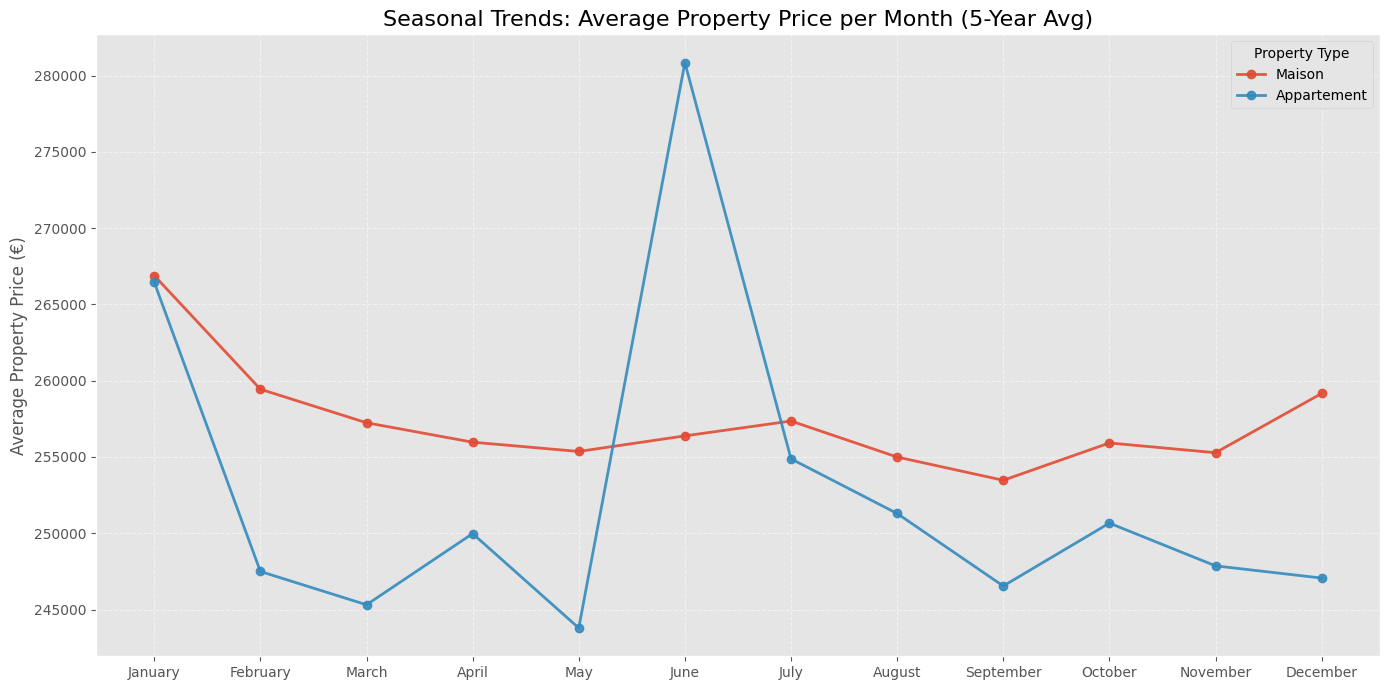

Monthly averages across 5 years (Maison & Appartement):
Type local  Appartement    Maison
Month_Name                       
January        266449.0  266889.0
February       247497.0  259443.0
March          245315.0  257244.0
April          249979.0  255971.0
May            243792.0  255363.0
June           280849.0  256385.0
July           254879.0  257358.0
August         251298.0  254998.0
September      246545.0  253474.0
October        250666.0  255920.0
November       247866.0  255282.0
December       247065.0  259165.0


In [10]:
import pandas as pd
import matplotlib.pyplot as plt


# Convert date column
df["Date mutation"] = pd.to_datetime(df["Date mutation"], errors="coerce")

# Keep only relevant columns and drop missing
df = df.dropna(subset=["Valeur fonciere", "Type local"])

# Optional: remove extreme outliers
df = df[df["Valeur fonciere"] < 2_000_000]

# Filter only Maison and Appartement
df = df[df["Type local"].isin(["Maison", "Appartement"])]

# Extract month name
df['Month_Name'] = df['Date mutation'].dt.month_name()

# Calculate average price per month for each Type local
monthly_avg = df.groupby(['Type local', 'Month_Name'])['Valeur fonciere'].mean().reset_index()

# Define month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Sort by month order
monthly_avg['Month_Name'] = pd.Categorical(monthly_avg['Month_Name'], categories=month_order, ordered=True)
monthly_avg = monthly_avg.sort_values('Month_Name')

# Plot
plt.figure(figsize=(14,7))
for property_type in ["Maison", "Appartement"]:
    subset = monthly_avg[monthly_avg['Type local'] == property_type]
    plt.plot(subset['Month_Name'], subset['Valeur fonciere'],
             marker='o', linewidth=2, alpha=0.9, label=property_type)

plt.title("Seasonal Trends: Average Property Price per Month (5-Year Avg)", fontsize=16)
plt.ylabel("Average Property Price (€)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Property Type")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Optional: print the monthly averages table
print("Monthly averages across 5 years (Maison & Appartement):")
print(monthly_avg.pivot(index='Month_Name', columns='Type local', values='Valeur fonciere').round(0))

In [11]:
import pandas as pd
import plotly.graph_objects as go

# Load DVF dataset
df = pd.read_csv("../data/processed/ValeursFoncieres_all.csv")

# Convert date
df["Date mutation"] = pd.to_datetime(df["Date mutation"], errors="coerce")

# Keep relevant columns and drop missing
df = df.dropna(subset=["Valeur fonciere", "Type local"])

# Optional: remove extreme outliers
df = df[df["Valeur fonciere"] < 2_000_000]

# Filter only Maison & Appartement
df = df[df["Type local"].isin(["Maison", "Appartement"])]

# Extract month names and short names
full_to_short = {
    'January': 'Jan', 'February': 'Feb', 'March': 'Mar', 'April': 'Apr',
    'May': 'May', 'June': 'Jun', 'July': 'Jul', 'August': 'Aug',
    'September': 'Sep', 'October': 'Oct', 'November': 'Nov', 'December': 'Dec'
}
df['Month_Name'] = df['Date mutation'].dt.month_name()
df['Month_Short'] = df['Month_Name'].map(full_to_short)

# Define month order
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Compute 5-year monthly averages per property type
monthly_data = {}
for prop_type in ["Maison", "Appartement"]:
    monthly_avg = df[df["Type local"] == prop_type].groupby("Month_Short")["Valeur fonciere"].mean().reset_index()
    monthly_avg['Month_Short'] = pd.Categorical(monthly_avg['Month_Short'], categories=month_order, ordered=True)
    monthly_avg = monthly_avg.sort_values("Month_Short")
    monthly_data[prop_type] = monthly_avg.set_index("Month_Short")["Valeur fonciere"]

# Combine into DataFrame
monthly_df = pd.DataFrame(monthly_data).reindex(month_order)

# Colors for the two types
colors = ['#4C78A8', '#F58518']  # Maison = blue, Appartement = orange

# Plotly figure
fig = go.Figure()
for i, prop_type in enumerate(["Maison", "Appartement"]):
    fig.add_trace(go.Scatter(
        x=monthly_df.index,
        y=monthly_df[prop_type],
        mode='lines+markers',
        name=prop_type,
        line=dict(color=colors[i], width=3),
        marker=dict(size=8),
        hovertemplate=f'<b>{prop_type}</b><br>Month: %{{x}}<br>Avg Price: €%{{y:,.0f}}<extra></extra>'
    ))

fig.update_layout(
    title='Property Price Trends - Seasonal 5-Year Monthly Averages',
    xaxis_title="",
    yaxis_title="Average Property Price (€)",
    hovermode='x unified',
    legend=dict(title="Property Type", yanchor="top", y=1.0, xanchor="left", x=1.02),
    width=1200,
    height=600,
    plot_bgcolor='white',
    font=dict(size=12)
)

fig.update_xaxes(tickangle=0)
fig.update_yaxes(gridcolor='lightgray')

fig.show()

# Optional: print monthly averages table
print("✅ Seasonal 5-Year Monthly Averages (Maison & Appartement):")
print(monthly_df.round(0))

✅ Seasonal 5-Year Monthly Averages (Maison & Appartement):
               Maison  Appartement
Month_Short                       
Jan          266889.0     266449.0
Feb          259443.0     247497.0
Mar          257244.0     245315.0
Apr          255971.0     249979.0
May          255363.0     243792.0
Jun          256385.0     280849.0
Jul          257358.0     254879.0
Aug          254998.0     251298.0
Sep          253474.0     246545.0
Oct          255920.0     250666.0
Nov          255282.0     247866.0
Dec          259165.0     247065.0


<hr>

## 2 - DATA LOADING & EXPLORATION


<style>
h1 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>
<hr>

### DATASETS

| Field Name             | Python Data Type       | Concise Definition                                  |
|------------------------|------------------------|-----------------------------------------------------|
| **date**        | `date`          | date mutation               | 
| **commune**           | `str`                 | Commune official Name       |
| **departement**             | `int`                 | first two digits in the Postal code. Extracted from `code_postale`; a unique identifier of the department region.                      |
| **code_postale**           | `int`                 |  FR Postal code        |  
| **valeur_fonciere**            | `float`                | Property's price (declaré)          | 
| **type**        | `str`          | Property variations: Appartement; Dépendance; Maison; Local industriel, commercial ou assimilé.               |             |
| **surface**        | `float`          | property surface m2               |             
| **nbr_pieces**        | `int`          | Nombre pieces principales        |    

### DATA TRANSFORMATION & SAVING
    - DVF 6 TXT files merged  into 1 CSV with selected columns:
    - arrondissements.csv file with seelected columns:
    - communes.csv file with selected columns:

#### DVF 2020-2025

#### LIGNES DE TRANSPORT EN COMMUN

In [ ]:
# LIGNES DE TRANSPORT EN COMMUN
df_lignes_transport = pd.read_csv("../data/raw/traces-des-lignes-de-transport-en-commun-idfm.csv", sep=";")
print("Lignes de transport en commun:")
display(df_lignes_transport.head())

Lignes de transport en commun:


,ID,Short Name,Long Name,Route Type,Color,Route URL,Shape,id_ilico,OperatorName,NetworkName,ID_Bus_Contrat,url,Type,long_name_first,geo_point_2d
0,IDFM:C00029,502,502,Bus,FBE324,NaN,"{""coordinates"": [[[2.605063, 48.801975], [2.60...",C00029,Keolis Grand Paris Vallée de la Marne,Marne et Brie,9.0,https://ilico.iledefrance-mobilites.fr/uploads...,HORAIRE|PLAN,5,"48.78188816972777, 2.6480891283837553"
1,IDFM:C01094,57,57,Bus,6E6E00,NaN,"{""coordinates"": [[[2.409755, 48.863434], [2.41...",C01094,RATP,NaN,NaN,https://www.ratp.fr/sites/default/files/lines-...,HORAIRE|PLAN,5,"48.83515885931267, 2.3687425840691674"
2,IDFM:C02220,Soir,Soir Mennecy,Bus,640082,NaN,NaN,C02220,Keolis Val d'Essonne Deux Vallées,Essonne Sud Est,31.0,https://ilico.iledefrance-mobilites.fr/uploads...,HORAIRE|PLAN,S,NaN
3,IDFM:C00527,6183,6183,Bus,640082,NaN,"{""coordinates"": [[[2.037603, 48.707024], [2.03...",C00527,Keolis Vélizy Vallée de la Bièvre,Vélizy Vallées,27.0,https://ilico.iledefrance-mobilites.fr/uploads...,HORAIRE|PLAN,6,"48.72894729625489, 2.0909603606050835"
4,IDFM:C02301,GPSO Bus,GPSO Bus,Bus,FF9900,NaN,"{""coordinates"": [[[2.182615, 48.825516], [2.18...",C02301,Origami / Mobicité,Grand Paris Seine Ouest,NaN,https://ilico.iledefrance-mobilites.fr/uploads...,HORAIRE|PLAN,G,"48.81986189913045, 2.1925887330951395"


#### STATUS D'OCCUPATION des RESIDENCES PRINCIPALES

In [12]:
# STATUS D'OCCUPATION des RESIDENCES PRINCIPALES
df_statuts_occupation = pd.read_csv("../data/raw/statuts-doccupation-des-residences-principales-des-communes-donnee-insee.csv", sep=";")
print("Statuts d'occupation des résidences principales:")
display(df_statuts_occupation.head())

Statuts d'occupation des résidences principales:


,Geo Point,Geo Shape,insee,propri,loc_prive,loc_hlm,loge_grat,objectid,loc_meuble
0,"48.3487428126, 2.56411763357","{""coordinates"": [2.564117633568488, 48.3487428...",77001,413.899704,27.570390,0.000000,15.365497,6,5.164409
1,"48.8432766256, 2.81653798016","{""coordinates"": [2.816537980161528, 48.8432766...",77018,1589.639610,445.547249,414.490793,25.076784,65,299.245565
2,"48.7736559886, 1.85178491669","{""coordinates"": [1.851784916691507, 48.7736559...",78050,211.000000,19.000000,0.000000,8.000000,79,0.000000
3,"48.6758272988, 2.04925351361","{""coordinates"": [2.049253513605204, 48.6758272...",91093,216.000000,12.000000,0.000000,4.000000,141,1.000000
4,"48.791668334, 2.33207260764","{""coordinates"": [2.332072607638279, 48.7916683...",94016,5193.592683,2562.411729,3775.432773,296.528775,188,1685.252539


<hr>

## 2 - DATA EXPLORATION


<style>
h1 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>
<hr>

### **a) DATA TRANSFORMATION**
